SUPERVISED LEARNING: MODEL SELECTION PIPELINE
=======================================================================================
Bu kod bloğunun amacı, etiketlenmiş (Positive/Neutral/Negative) veri seti üzerinde 5 farklı makine öğrenmesi algoritmasını eğitip kıyaslamaktır.

Bu kodda şu adımlar uygulanmıştır:
1. Veri İzolasyonu (Train/Test Split): Modelin daha önce hiç görmediği verilerdeki 
   başarısını ölçmek için veri seti %80 Eğitim, %20 Test olarak ayrılmıştır.
2. Algoritma Doğası Gereği Ölçeklendirme: Ağaç tabanlı modeller (XGBoost, RF vb.) 
   ölçeklendirmeye ihtiyaç duymazken, mesafe tabanlı KNN algoritması için 
   StandardScaler kullanılmıştır.

Veri şu adresten okunuyor: ../data/gold_sentiment_analysis

=== TÜM MODELLERİN SONUÇLARI ===
        Model  Accuracy  F1-Score  Time(s)
      XGBoost  0.722493  0.738042 0.862959
     CatBoost  0.718230  0.733138 1.307266
     LightGBM  0.718128  0.734905 1.196052
Random Forest  0.708993  0.725697 1.588623
          KNN  0.700771  0.712051 0.769104


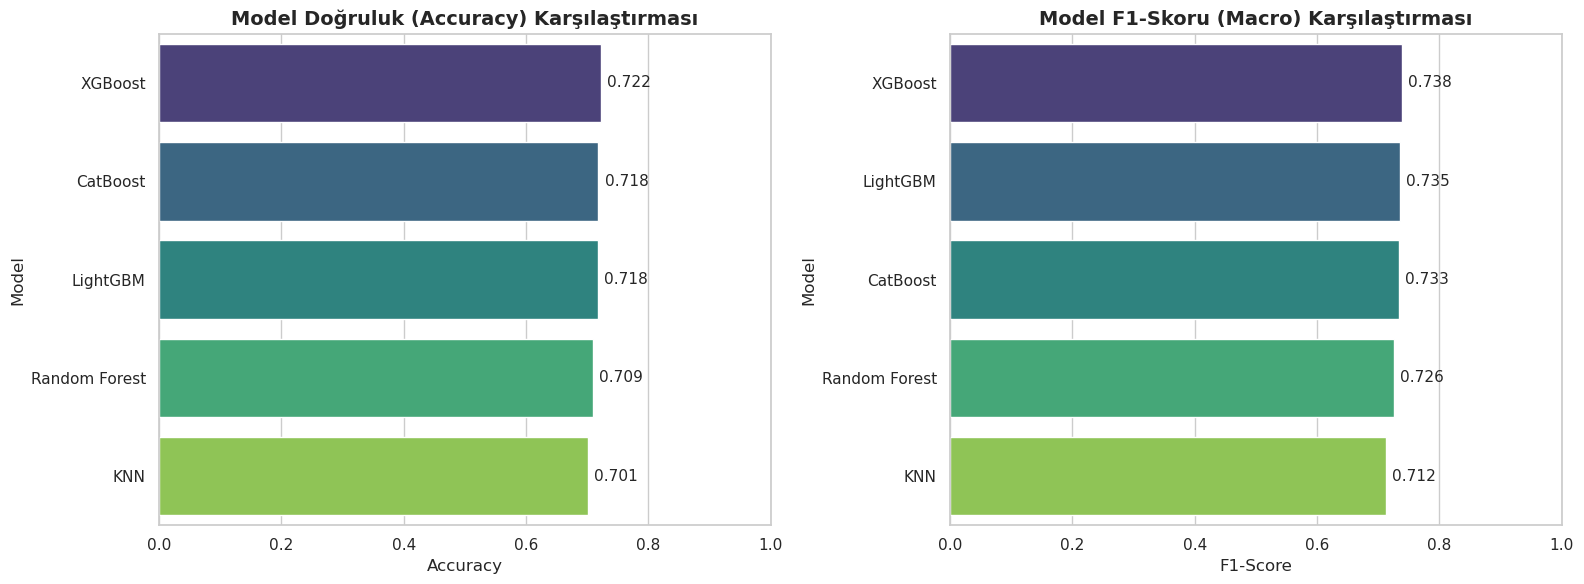


=== AĞAÇ TABANLI MODELLER İÇİN ÖZELLİK ÖNEMİ ÇIKARILIYOR ===


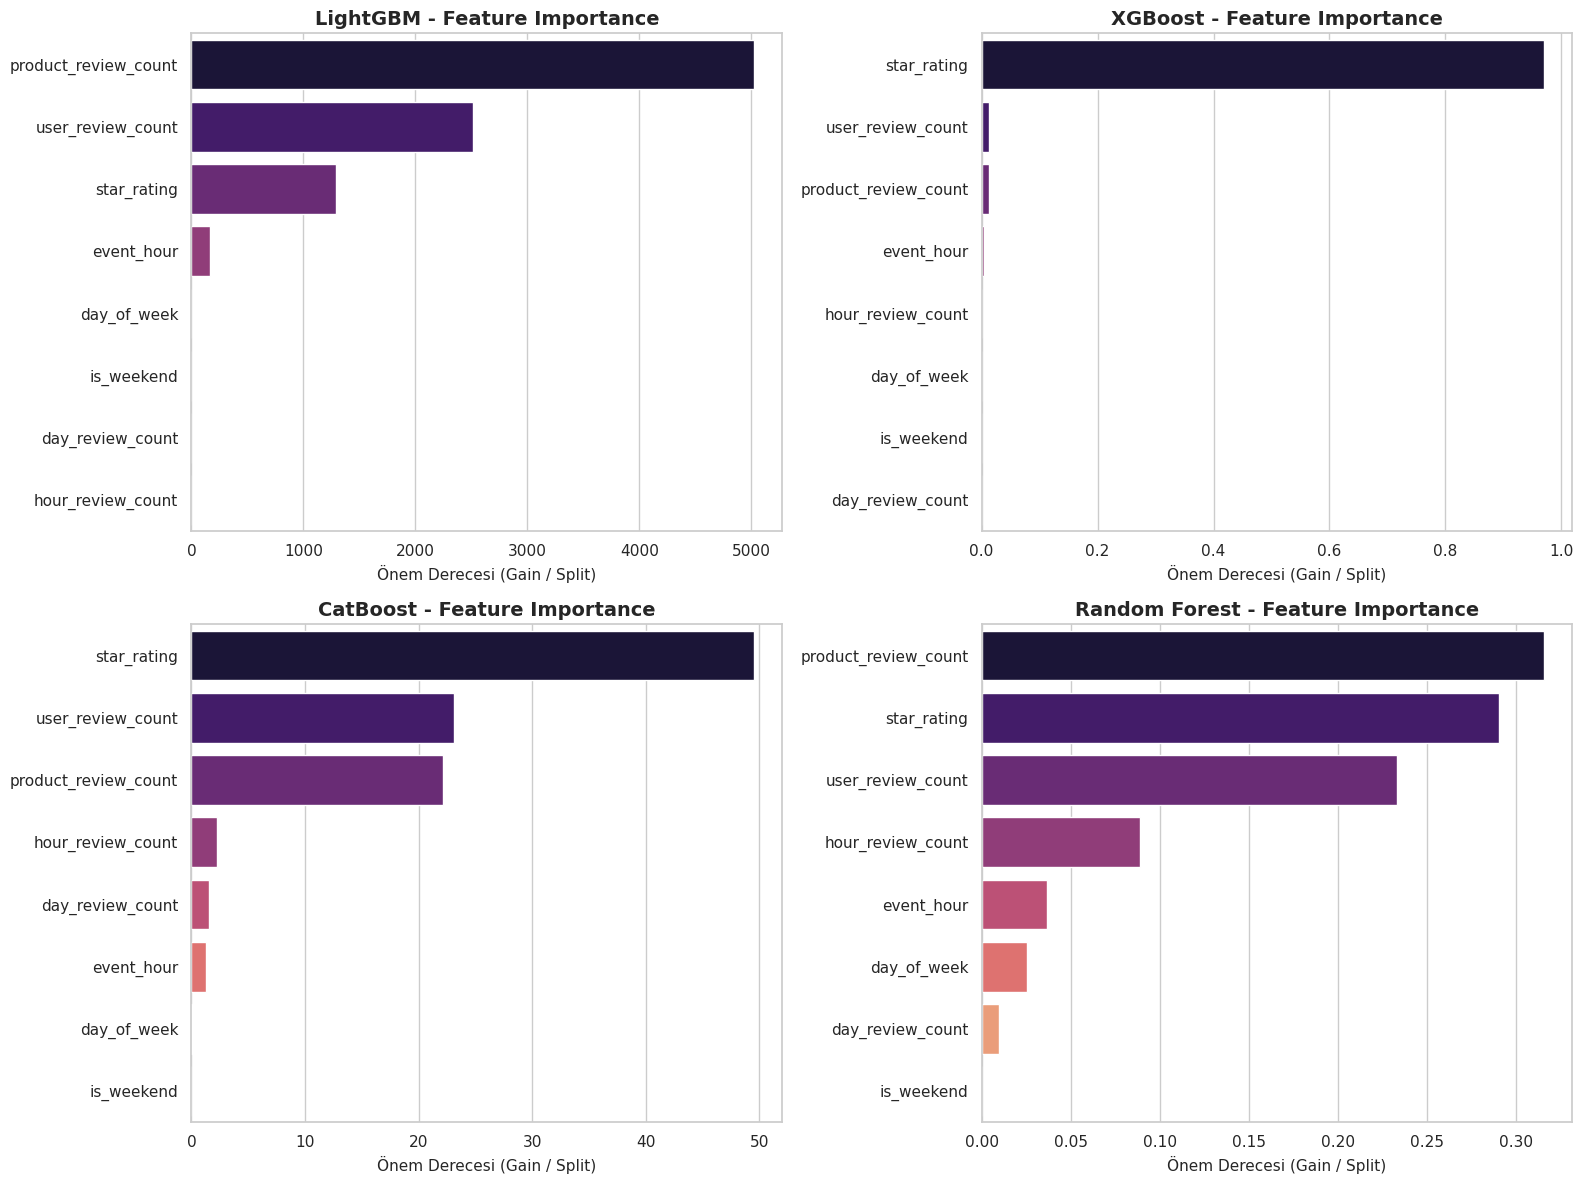

In [4]:
# ==========================================
# 1. KÜTÜPHANELER VE KONFİGÜRASYON
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pyspark.sql import SparkSession
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings("ignore")
# Modeller
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# ==========================================
# 2. VERİ YÜKLEME 
# ==========================================
import os
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ML_Comparison_Pipeline") \
    .config("spark.driver.memory", "2g") \
    .config("spark.jars.packages", "io.delta:delta-spark_2.12:3.1.0") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .getOrCreate()

# Bulunduğumuz klasörü tespit ediyoruz
current_dir = os.getcwd()

gold_path = "../data/gold_sentiment_analysis"
print(f"Veri şu adresten okunuyor: {gold_path}")

df_spark = spark.read.format("delta").load(gold_path)

# Özellik seçimi ve Pandas'a geçiş
selected_features = [
    "star_rating", "event_hour", "day_of_week", "is_weekend",
    "user_review_count", "product_review_count", "day_review_count", 
    "hour_review_count", "sentiment_label"
]
df = df_spark.select(selected_features).toPandas()
spark.stop()
# ==========================================
# 3. ÖN İŞLEME (PREPROCESSING)
# ==========================================
label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
df['target'] = df['sentiment_label'].map(label_map)

X = df.drop(['sentiment_label', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mesafe tabanlı modeller (KNN) için ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 4. MODEL EĞİTİM VE KIYASLAMA SUITE
# ==========================================
models = {
    "LightGBM": lgb.LGBMClassifier(learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1),
    "XGBoost": xgb.XGBClassifier(eval_metric='mlogloss', random_state=42),
    "CatBoost": CatBoostClassifier(iterations=100, verbose=0, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

results = []

for name, model in models.items():
    start = time.time()
    # Model eğitimi (KNN için ölçeklenmiş veri)
    if name == "KNN":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    runtime = time.time() - start
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds, average='macro'),
        "Time(s)": runtime
    })
    
# ==========================================
# 5. SONUÇLARIN GÖRSELLEŞTİRİLMESİ
# ==========================================
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print("\n=== TÜM MODELLERİN SONUÇLARI ===")
print(results_df.to_string(index=False))

# Grafik Çizimi
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Renk paleti
palette = sns.color_palette("viridis", len(models))

# 1. Grafik: Accuracy Karşılaştırması
sns.barplot(x="Accuracy", y="Model", data=results_df.sort_values("Accuracy", ascending=False), 
            ax=axes[0], palette=palette)
axes[0].set_title("Model Doğruluk (Accuracy) Karşılaştırması", fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 1.0)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_width():.3f}", (p.get_width() + 0.01, p.get_y() + p.get_height() / 2),
                     ha='left', va='center', fontsize=11)

# 2. Grafik: F1-Score Karşılaştırması
sns.barplot(x="F1-Score", y="Model", data=results_df.sort_values("F1-Score", ascending=False), 
            ax=axes[1], palette=palette)
axes[1].set_title("Model F1-Skoru (Macro) Karşılaştırması", fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 1.0)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_width():.3f}", (p.get_width() + 0.01, p.get_y() + p.get_height() / 2),
                     ha='left', va='center', fontsize=11)

plt.tight_layout()
plt.show()
# 6. FEATURE IMPORTANCE 
# ==========================================
print("\n=== AĞAÇ TABANLI MODELLER İÇİN ÖZELLİK ÖNEMİ ÇIKARILIYOR ===")

# KNN'in feature_importances_ niteliği olmadığı için onu sözlükten çıkararak filtreliyoruz
tree_models = {k: v for k, v in models.items() if k != "KNN"}

# 2x2'lik bir grafik ızgarası (grid) oluşturuyoruz
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # Döngüde kolay indekslemek için düzleştiriyoruz

for idx, (name, model) in enumerate(tree_models.items()):
    # CatBoost'un özellik önemi çağırma fonksiyonu diğerlerinden biraz farklıdır
    if name == "CatBoost":
        importances = model.get_feature_importance()
    else:
        importances = model.feature_importances_
        
    # Özellikleri ve önem derecelerini bir DataFrame'de toplayıp sıralıyoruz
    imp_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    # Her bir model için bar grafiği çizdiriyoruz
    sns.barplot(x='Importance', y='Feature', data=imp_df, ax=axes[idx], palette='magma')
    axes[idx].set_title(f"{name} - Feature Importance", fontsize=14, fontweight='bold')
    axes[idx].set_xlabel("Önem Derecesi (Gain / Split)", fontsize=11)
    axes[idx].set_ylabel("")

plt.tight_layout()
plt.show()

In [2]:
# Veri setinin tam boyutunu  kontrol et
# İlk 5 ve Son 5 satırı göster 
display(df)

,star_rating,event_hour,day_of_week,is_weekend,user_review_count,product_review_count,day_review_count,hour_review_count,sentiment_label,target
0,5.0,13,2,0,4,3,44260,21101,Neutral,1
1,5.0,12,2,0,2,108,44260,18159,Neutral,1
2,3.0,13,2,0,2,11,44260,21101,Neutral,1
3,5.0,13,2,0,1,3,44260,21101,Neutral,1
4,5.0,12,2,0,2,1006,44260,18159,Neutral,1
...,...,...,...,...,...,...,...,...,...,...
49255,0.0,13,2,0,12859,12859,44260,21101,Negative,0
49256,0.0,13,2,0,12859,12859,44260,21101,Negative,0
49257,0.0,13,2,0,12859,12859,44260,21101,Negative,0
49258,0.0,13,2,0,12859,12859,44260,21101,Negative,0


K-MEANS ile MÜŞTERİ SEGMENTASYONU (GÖZETİMSİZ ÖĞRENME)
=======================================================================================
Bu kod bloğunun amacı, verisetimizdeki müşterileri davranışlarına göre 
3 farklı kümeye ayırmaktır.
Büyük veri ile çalışılması nedeni ile koda şu optimizasyonlar eklenmiştir:
1. Ölçeklendirme (StandardScaler): K-Means uzaklık ölçerek çalışır. "Yorum Sayısı" gibi 
   büyük sayıların, Yıldız Puanını (1-5) ezmemesi için tüm veriler aynı ölçeğe getirildi.
2. Gizli Özellik Keşfi (Random Forest): K-Means kümeleri ayırır ama nedenini söylemez. 
   Bu yüzden kümeler oluştuktan sonra bir Random Forest modeli eğitilerek, bu 3 profili 
   birbirinden ayıran en önemli özellikler (Feature Importance) tespit edildi.
3. Görselleştirme Optimizasyonu: 49 bin noktanın hepsini grafiğe basmak bilgisayarı 
   kilitleyeceği (overplotting) için, dağılım grafiği (Scatter Plot) verinin rastgele 
   seçilmiş %5'lik bir örneklemi üzerinden çizdirildi.

Veri K-Means için hazırlanıyor (VectorAssembler & StandardScaler)...
K-Means Modeli 49 Bin Satır üzerinde eğitiliyor...

[BAŞARILI] K-Means (k=3) Silhouette Skoru: 0.9079
(Not: Bu skor -1 ile 1 arasındadır. 1'e ne kadar yakınsa kümeler o kadar iyi ayrışmış demektir.)


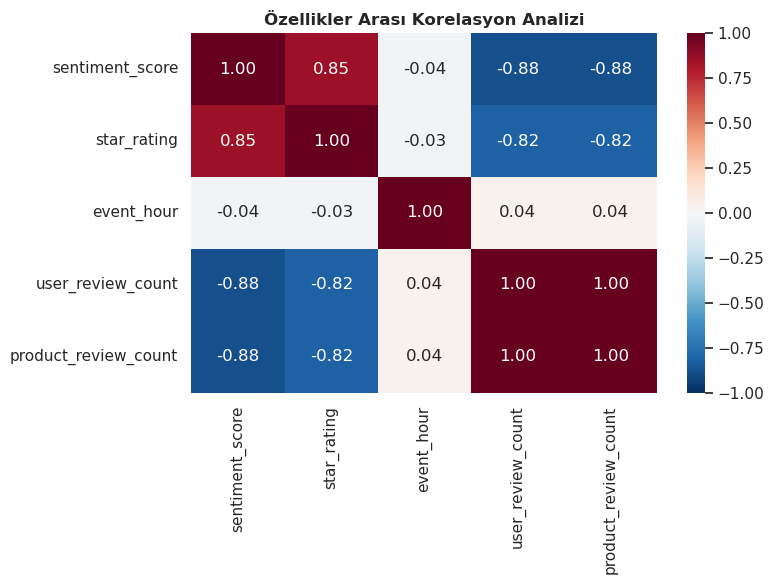


K-Means Kümelerini Açıklayan Özelliklerin Önemi Hesaplanıyor...


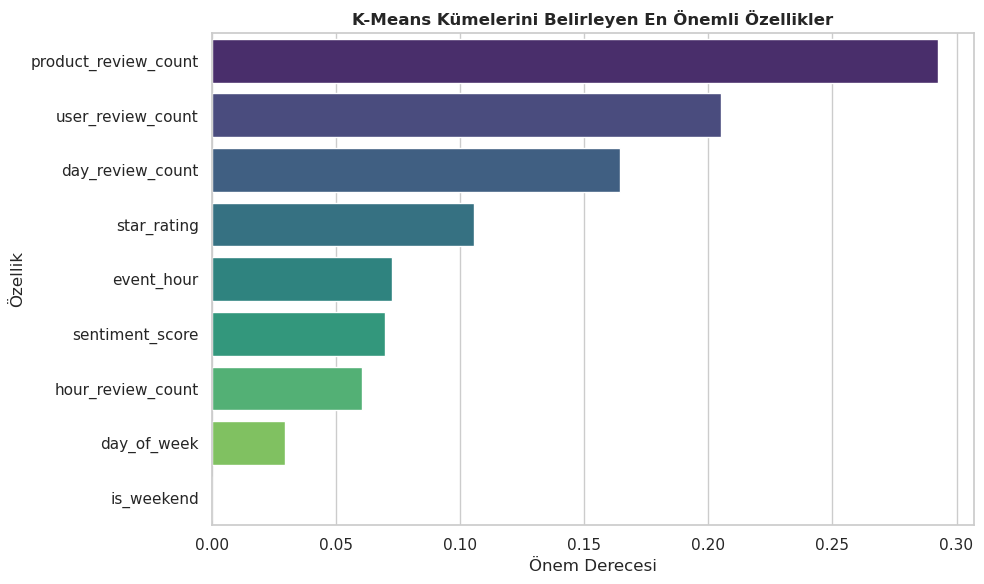

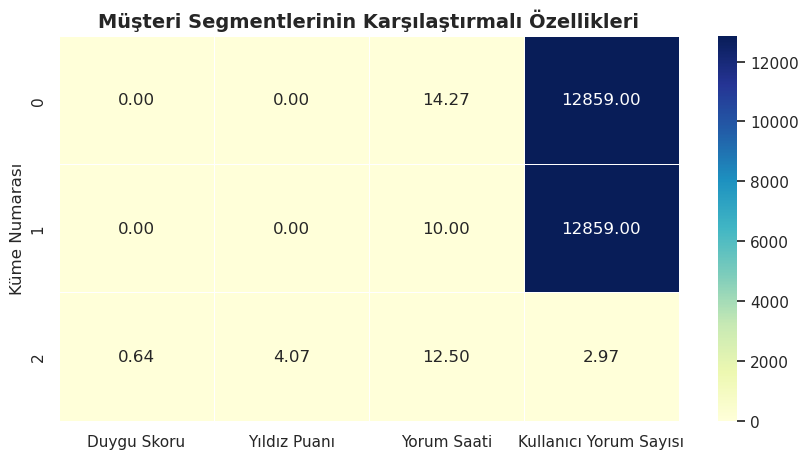

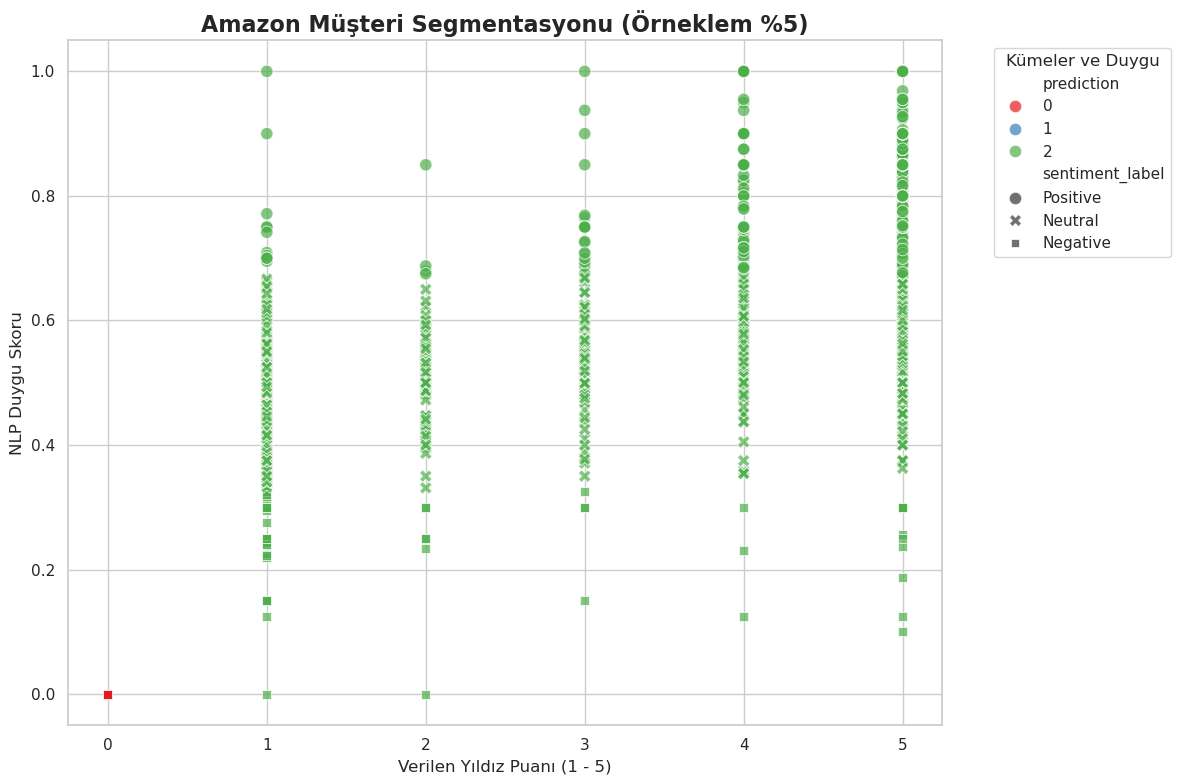

In [5]:
# ==========================================
# 1. KÜTÜPHANELER VE VERİ YÜKLEME
# ==========================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.classification import RandomForestClassifier
from pyspark.sql.functions import avg
import warnings
warnings.filterwarnings("ignore")
# Spark Oturumu
spark = SparkSession.builder \
    .appName("KMeans_Segmentation") \
    .config("spark.driver.memory", "2g") \
    .config("spark.jars.packages", "io.delta:delta-spark_2.12:3.1.0") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .getOrCreate()

gold_path = "../data/gold_sentiment_analysis"
df_spark = spark.read.format("delta").load(gold_path)

# ==========================================
# 2. K-MEANS İÇİN ÖN İŞLEME (ÖLÇEKLENDİRME)
# ==========================================
print("Veri K-Means için hazırlanıyor (VectorAssembler & StandardScaler)...")

# Modele girecek sayısal özellikler
feature_cols = [
    'sentiment_score', 'star_rating', 'event_hour', 
    'day_of_week', 'is_weekend', 'user_review_count',
    'product_review_count', 'day_review_count', 'hour_review_count'
]

# 1. Özellikleri tek bir vektörde topla
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
df_assembled = assembler.transform(df_spark)

# 2. K-Means mesafe tabanlı olduğu için verileri standartlaştır (Çok Önemli!)
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

# ==========================================
# 3. K-MEANS MODEL EĞİTİMİ VE DEĞERLENDİRME
# ==========================================
print("K-Means Modeli 49 Bin Satır üzerinde eğitiliyor...")
kmeans = KMeans(featuresCol="features", predictionCol="prediction", k=3, seed=42)
kmeans_model = kmeans.fit(df_scaled)
predictions = kmeans_model.transform(df_scaled)

evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="prediction")
silhouette = evaluator.evaluate(predictions)

print(f"\n[BAŞARILI] K-Means (k=3) Silhouette Skoru: {silhouette:.4f}")
print("(Not: Bu skor -1 ile 1 arasındadır. 1'e ne kadar yakınsa kümeler o kadar iyi ayrışmış demektir.)")

# ==========================================
# 4. KORELASYON ANALİZİ GRAFİĞİ
# ==========================================
features_for_corr = ['sentiment_score', 'star_rating', 'event_hour', 'user_review_count', 'product_review_count']
corr_df = predictions.select(*features_for_corr).toPandas().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f")
plt.title("Özellikler Arası Korelasyon Analizi", fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 5. FEATURE IMPORTANCE (RANDOM FOREST İLE)
# ==========================================
print("\nK-Means Kümelerini Açıklayan Özelliklerin Önemi Hesaplanıyor...")
rf = RandomForestClassifier(labelCol="prediction", featuresCol="features", predictionCol="rf_prediction", numTrees=20, seed=42)
rf_model = rf.fit(predictions)

importances = rf_model.featureImportances.toArray()
importance_df = pd.DataFrame({'Özellik': feature_cols, 'Önem Derecesi': importances})
importance_df = importance_df.sort_values(by='Önem Derecesi', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Önem Derecesi', y='Özellik', palette='viridis')
plt.title("K-Means Kümelerini Belirleyen En Önemli Özellikler", fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 6. KÜMELERİN ORTALAMA ÖZELLİKLERİ (ISI HARİTASI)
# ==========================================
# Not: Hangi kümenin (0, 1, 2) hangi profile uyduğunu bu haritaya bakarak anlayacağız.
cluster_features = predictions.groupBy("prediction").agg(
    avg("sentiment_score").alias("Duygu Skoru"),
    avg("star_rating").alias("Yıldız Puanı"),
    avg("event_hour").alias("Yorum Saati"),
    avg("user_review_count").alias("Kullanıcı Yorum Sayısı")
).toPandas()

cluster_features = cluster_features.set_index('prediction').sort_index()

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_features, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=.5)
plt.title('Müşteri Segmentlerinin Karşılaştırmalı Özellikleri', fontsize=14, fontweight='bold')
plt.ylabel("Küme Numarası")
plt.show()

# ==========================================
# 7. KÜMELERİN DAĞILIMI (SCATTER PLOT)
# ==========================================
# BİLGİSAYAR MÜHENDİSLİĞİ DOKUNUŞU: 49 bin satırı scatter plot'a basmak üst üste binme (overplotting) yapar.
# Dağılımı net görmek için verinin %5'ini (yaklaşık 2500 satır) örnekliyoruz.
sampled_predictions = predictions.sample(fraction=0.05, seed=42)

predictions_pd = sampled_predictions.select(
    'star_rating', 'sentiment_score', 'sentiment_label', 'prediction'
).toPandas()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

scatter = sns.scatterplot(
    data=predictions_pd,
    x='star_rating', 
    y='sentiment_score', 
    hue='prediction', # Küme numarasına göre renklendirme
    style='sentiment_label', 
    palette='Set1', 
    s=80, 
    alpha=0.7 
)
plt.title('Amazon Müşteri Segmentasyonu (Örneklem %5)', fontsize=16, fontweight='bold')
plt.xlabel('Verilen Yıldız Puanı (1 - 5)', fontsize=12)
plt.ylabel('NLP Duygu Skoru', fontsize=12)
plt.legend(title='Kümeler ve Duygu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# İşlem bitince RAM'i temizle
spark.stop()